# SpliceAI Gene-Level Scorer

Calculates SpliceAI scores across an entire gene's genomic sequence and visualizes them with annotated splice sites from all transcript isoforms.

In [1]:
from Bio import SeqIO
from Bio.Seq import Seq
import csv
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter
import numpy as np
import os
import pandas as pd
import re
import torch
from tqdm.notebook import tqdm

# SpliceAI imports
from keras.models import load_model
from pkg_resources import resource_filename
from spliceai.utils import one_hot_encode

2025-11-29 20:48:02.154974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-29 20:48:02.183711: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-29 20:48:03.011577: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/tmp/ipykernel_121115/3522256048.py:17: DeprecationWarning: pkg_resources is deprecated as 

## Configuration and Data Loading

In [2]:
# GFF3 from Ensembl Genomes
gff_path = "../dependencies/Homo_sapiens.GRCh38.114.gff3"
# hg38 fasta from UCSC
fasta_path = "../dependencies/GRCh38.p14.genome.fa"

In [3]:
# Build a dictionary: {chromosome_name: sequence}
print("Loading genome...")
genome = {}
for record in SeqIO.parse(fasta_path, "fasta"):
    genome[record.id] = record.seq
print(f"Loaded {len(genome)} chromosomes")

Loading genome...
Loaded 706 chromosomes


In [4]:
# Load SpliceAI models
print("Loading SpliceAI models...")
paths = ("../dependencies/SpliceAI/spliceai/models/spliceai{}.h5".format(x) for x in range(1, 6))
spliceai_models = [load_model(x) for x in paths]
print(f"Loaded {len(spliceai_models)} SpliceAI models")

Loading SpliceAI models...


I0000 00:00:1764449291.288075  121115 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18327 MB memory:  -> device: 0, name: NVIDIA RTX 4000 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9


Loaded 5 SpliceAI models


## Load and Parse GFF3 Annotations

In [5]:
def load_gff_preserve_attributes(gff_file):
    return pd.read_csv(
        gff_file,
        sep="\t",
        comment="#",
        header=None,
        dtype=str,
        quoting=csv.QUOTE_NONE,
        names=[
            "seqid", "source", "type", "start", "end", "score",
            "strand", "phase", "attributes"
        ],
    )

In [6]:
def extract_attr(attr_str, key):
    """Extracts a single attribute from GFF attributes column"""
    for part in attr_str.split(";"):
        if part.startswith(key + "="):
            return part.split("=", 1)[1]
    return None
    
def parse_attributes(df):
    for k in ["ID", "Parent", "biotype", "tag"]:
        df[k] = df["attributes"].apply(lambda x: extract_attr(x, k))
        
    df["ID_stripped"] = df["ID"].fillna("").str.split(":", n=1).str[-1]
    df["Parent_stripped"] = df["Parent"].fillna("").str.split(":", n=1).str[-1]
    
    return df

In [7]:
def is_chromosome(seqid):
    return bool(re.match(r'^(chr)?([1-9]|1[0-9]|2[0-2]|X|Y)$', str(seqid)))

def prepend_chr(seqid):
    seqid = str(seqid)
    return seqid if seqid.startswith("chr") else f"chr{seqid}"

In [8]:
print("Loading GFF3 annotations...")
gff = load_gff_preserve_attributes(gff_path)
gff = parse_attributes(gff)

gff["start"] = gff["start"].astype(int)
gff["end"] = gff["end"].astype(int)

# Filter to chromosomes only and add 'chr' prefix
gff = gff[gff["seqid"].apply(is_chromosome)].copy()
gff["seqid"] = gff["seqid"].apply(prepend_chr)

print(f"Loaded {len(gff)} annotation records")

Loading GFF3 annotations...
Loaded 4092338 annotation records


## Transcript Extraction Functions

In [9]:
def get_transcript_info(transcript_id, gff_df):
    # Get transcript record
    transcript_records = gff_df[
        (gff_df["ID_stripped"] == transcript_id) &
        (gff_df["type"].isin(["mRNA", "transcript", "pseudogenic_transcript", "lnc_RNA"]))
    ]
    
    if len(transcript_records) == 0:
        raise ValueError(f"Transcript {transcript_id} not found")
    
    transcript = transcript_records.iloc[0]
    
    # Get all exons for this transcript
    exon_records = gff_df[
        (gff_df["Parent_stripped"] == transcript_id) &
        (gff_df["type"] == "exon")
    ].copy()
    
    if len(exon_records) == 0:
        raise ValueError(f"No exons found for transcript {transcript_id}")
    
    # Sort by rank
    exon_records["rank"] = exon_records["attributes"].apply(
        lambda x: int(extract_attr(x, "rank"))
    )
    exon_records = exon_records.sort_values("rank")
    
    exons = [
        {"start": row["start"], "end": row["end"], "rank": row["rank"]}
        for _, row in exon_records.iterrows()
    ]
    
    return {
        "transcript_id": transcript_id,
        "start": exon_records.sort_values("start").iloc[0]["start"],
        "end": exon_records.sort_values("start").iloc[-1]["end"],
        "chrom": transcript["seqid"],
        "strand": transcript["strand"],
        "biotype": transcript["biotype"],
        "exons": exons,
        "gene_id": transcript["Parent_stripped"]
    }

In [10]:
def get_gene_sequence(gene_info, genome_dict):
    """
    Extract the full gene sequence spanning all transcripts.
    Handles strand orientation.
    
    Args:
        gene_info: dict from get_gene_info() with keys chrom, strand, start, end
        genome_dict: dictionary of genome sequences
    
    Returns:
        str: gene sequence (reverse complemented if on negative strand)
    """
    chrom = gene_info["chrom"]
    strand = gene_info["strand"]
    genomic_start = gene_info["start"]
    genomic_end = gene_info["end"]
    
    # Extract sequence (GFF is 1-indexed)
    seq = genome_dict[chrom][genomic_start - 1 : genomic_end]
    
    # Reverse complement if on negative strand
    if strand == "-":
        seq = seq.reverse_complement()
    
    return str(seq)

In [11]:
def get_splice_sites_genomic(transcript_info, gene_start, gene_end):
    """
    Get positions of annotated splice sites in genomic coordinates.
    For use with gene-level sequence scoring.
    
    Args:
        transcript_info: dict with transcript metadata
        gene_start: genomic start position of the gene
        gene_end: genomic end position of the gene
    
    Returns:
        dict with keys:
        - acceptor_sites: list of genomic positions
        - donor_sites: list of genomic positions  
        - exon_regions: list of (start, end) tuples in genomic coords
    """
    strand = transcript_info["strand"]
    exons = transcript_info["exons"]
    
    acceptor_sites = []
    donor_sites = []
    exon_regions = []
    
    for i, exon in enumerate(exons):
        if strand == "+":
            exon_regions.append((exon["start"], exon["end"]))
            if i > 0:
                acceptor_sites.append(exon["start"])
            if i < len(exons) - 1:
                donor_sites.append(exon["end"])
        else:
            exon_regions.append((exon["start"], exon["end"]))            
            if i > 0:
                acceptor_sites.append(exon["end"])
            if i < len(exons) - 1:
                donor_sites.append(exon["start"])
    
    return {
        "acceptor_sites": sorted(acceptor_sites),
        "donor_sites": sorted(donor_sites),
        "exon_regions": sorted(exon_regions)
    }

In [12]:
def get_all_transcripts_for_gene(gene_id, gff_df):
    """
    Get all transcript IDs for a given gene.
    
    Args:
        gene_id: Gene ID (e.g., ENSG00000066735)
        gff_df: GFF dataframe
    
    Returns:
        list of transcript IDs
    """
    transcript_records = gff_df[
        (gff_df["Parent_stripped"] == gene_id) &
        (gff_df["type"].isin(["mRNA", "transcript", "pseudogenic_transcript", "lnc_RNA"]))
    ]
    
    return transcript_records["ID_stripped"].tolist()

In [13]:
def get_gene_info(gene_id, gff_df):
    """
    Get gene-level information including genomic range across all transcripts.
    
    Args:
        gene_id: Gene ID (e.g., ENSG00000066735)
        gff_df: GFF dataframe
    
    Returns:
        dict with keys: gene_id, chrom, strand, start, end (genomic coordinates)
    """
    # Get gene record
    gene_records = gff_df[
        (gff_df["ID_stripped"] == gene_id) &
        (gff_df["type"].isin(["gene", "ncRNA_gene", "pseudogene"]))
    ]
    
    if len(gene_records) == 0:
        raise ValueError(f"Gene {gene_id} not found")
    
    gene = gene_records.iloc[0]
    
    # Get all transcripts for this gene to find full genomic range
    transcript_ids = get_all_transcripts_for_gene(gene_id, gff_df)
    
    all_starts = []
    all_ends = []
    
    for tid in transcript_ids:
        t_info = get_transcript_info(tid, gff_df)
        all_starts.append(t_info['start'])
        all_ends.append(t_info['end'])
    
    return {
        'gene_id': gene_id,
        'gene_name': extract_attr(gene['attributes'], 'Name'),
        'chrom': gene['seqid'],
        'strand': gene['strand'],
        'start': min(all_starts) if all_starts else int(gene['start']),
        'end': max(all_ends) if all_ends else int(gene['end'])
    }

In [14]:
def get_overlapping_transcripts(chrom, start, end, gff_df, exclude_gene_id=None):
    """
    Find all transcripts that overlap with a genomic region.
    
    Args:
        chrom: Chromosome name (e.g., 'chr17')
        start: Genomic start position
        end: Genomic end position
        gff_df: GFF dataframe
        exclude_gene_id: Optional gene ID to exclude (e.g., to exclude the main gene)
    
    Returns:
        list of transcript IDs that overlap with the region
    """
    # Find all transcripts on this chromosome
    overlapping_transcripts = gff_df[
        (gff_df["seqid"] == chrom) &
        (gff_df["type"].isin(["mRNA", "transcript", "pseudogenic_transcript", "lnc_RNA"])) &
        (gff_df["end"] >= start) &
        (gff_df["start"] <= end)
    ]
    
    # Optionally exclude transcripts from a specific gene
    if exclude_gene_id:
        overlapping_transcripts = overlapping_transcripts[
            overlapping_transcripts["Parent_stripped"] != exclude_gene_id
        ]
    
    return overlapping_transcripts["ID_stripped"].tolist()

## SpliceAI Scoring with Tiling

In [15]:
def score_sequence_with_model(model, seq, pad_left, pad_right):
    """
    Score a single sequence with a single SpliceAI model.
    
    Returns:
        np.array of shape (seq_len, 3) with scores for [none, acceptor, donor]
    """
    # Add padding
    padded_seq = pad_left + seq + pad_right
    
    # One-hot encode
    encoded = one_hot_encode(padded_seq)
    
    # Add batch dimension
    encoded_batch = np.expand_dims(encoded, axis=0)
    
    # Predict
    with torch.no_grad():
        preds = model.predict(encoded_batch, verbose=0)  # shape: (1, seq_len, 3)
    
    return preds[0]  # shape: (seq_len, 3)

In [16]:
def tile_and_score_sequence(sequence, models, window_size=5000):
    """
    Tile a long sequence and score it with SpliceAI.
    
    Args:
        sequence: DNA sequence string
        models: list of SpliceAI models
        window_size: size of each window (default 5000, SpliceAI's max context)
    
    Returns:
        np.array of shape (seq_len, 3) with averaged scores
    """
    step_size = 5000
    seq_len = len(sequence)
    
    # If sequence is short enough, score it directly
    if seq_len <= window_size:
        all_model_scores = []
        for model in models:
            scores = score_sequence_with_model(model, sequence, "N" * 5000, "N" * 5000)
            all_model_scores.append(scores)
        return np.mean(all_model_scores, axis=0)
    
    # Initialize arrays for accumulating scores and counts
    score_sum = np.zeros((seq_len, 3))
    score_count = np.zeros(seq_len)
    
    # Generate windows
    windows = []
    start = 0
    while start < seq_len:
        end = min(start + window_size, seq_len)
        windows.append((start, end))
        if end == seq_len:
            break
        start += step_size
    
    print(f"Scoring sequence of length {seq_len:,} bp using {len(windows)} windows...")
    
    # Score each window with all models
    for window_idx, (start, end) in enumerate(tqdm(windows, desc="Scoring windows")):
        window_seq = sequence[start:end]
        window_len = len(window_seq)
        
        left_flank_len = min(start, 5000)
        left_flank = sequence[start - left_flank_len:start]
        if left_flank_len < 5000:
            left_flank = "N" * (5000 - left_flank_len) + left_flank

        right_flank_len = min(len(sequence) - end, 5000)
        right_flank = sequence[end:end+5000]
        if right_flank_len < 5000:
            right_flank = right_flank + "N" * (5000 - right_flank_len)
        
        # Score with all models and average
        all_model_scores = []
        for model in models:
            scores = score_sequence_with_model(model, window_seq, left_flank, right_flank)
            all_model_scores.append(scores)
        
        avg_scores = np.mean(all_model_scores, axis=0)  # shape: (window_len, 3)
        
        # Accumulate scores
        score_sum[start:end] += avg_scores
        score_count[start:end] += 1
    
    # Average overlapping predictions
    final_scores = score_sum / score_count[:, np.newaxis]
    
    return final_scores

## Plotting Functions

In [17]:
def plot_spliceai_scores(scores, splice_sites_list, gene_info, genomic_start, genomic_end, 
                         additional_transcript_models=None, custom_tracks=None, region_of_interest=None, 
                         bbox_to_anchor=None, figsize=(20, 10), dpi=300, height_ratios=None):
    """
    Plot SpliceAI scores with annotated splice sites using genomic coordinates.

    Args:
        scores: np.array of shape (seq_len, 3) with [none, acceptor, donor]
        splice_sites_list: list of splice_sites dicts (one per transcript) with genomic coordinates
        gene_info: dict with gene metadata
        genomic_start: start position in genome
        genomic_end: end position in genome
        additional_transcript_models: optional list of dicts with additional transcript info
        custom_tracks: optional list of custom genomic regions to display on the same plot as transcripts
                        Each track should be a dict with keys: 'name', 'regions' (list of (start, end) tuples), 
                       'color' (optional), 'label' (optional)
        region_of_interest: tuple of genomic coordinates to zoom on
        bbox_to_anchor: bbox_to_anchor for scores subplot
        figsize: tuple for figure size
        dpi: resolution
    """
    seq_len = len(scores)
    
    # Create genomic coordinate positions
    genomic_positions = np.arange(genomic_start, genomic_end + 1)
    if gene_info["strand"] == "-":
        # Reverse the scores
        scores = scores[::-1, :]

    # Ensure we have the right number of positions
    assert len(genomic_positions) == seq_len

    if region_of_interest is not None:
        assert genomic_start <= region_of_interest[0] and region_of_interest[0] <= genomic_end
        assert genomic_start <= region_of_interest[1] and region_of_interest[1] <= genomic_end
        
        scores = scores[region_of_interest[0] - genomic_start: region_of_interest[1] - genomic_start + 1, :]
        genomic_start = region_of_interest[0]
        genomic_end = region_of_interest[1]
        genomic_positions = np.arange(genomic_start, genomic_end + 1)
    
    fig, axes = plt.subplots(2, 1, figsize=figsize, dpi=dpi, height_ratios=height_ratios, sharex=True)

    tlabel = f"{gene_info['gene_name']} ({gene_info['gene_id']})"
    fig.suptitle(f'SpliceAI Predictions for {tlabel}')

    # SpliceAI Predictions
    ax = axes[0]
    ax.plot(genomic_positions, scores[:, 1], label='Acceptor', color='tab:orange', alpha=0.7, linewidth=1)
    ax.plot(genomic_positions, scores[:, 2], label='Donor', color='tab:blue', alpha=0.7, linewidth=1)
    ax.legend(loc='lower right', ncols=2, bbox_to_anchor=bbox_to_anchor)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Transcript Models
    ax = axes[1]
    # Get all transcript models
    all_models = additional_transcript_models if additional_transcript_models else []
    n_transcripts = len(all_models)
    n_custom_tracks = len(custom_tracks) if custom_tracks else 0
    n_total_tracks = n_transcripts + n_custom_tracks

    # Calculate y-position for each track
    y_height = 1.0 / (n_total_tracks + 1) if n_total_tracks > 0 else 0.5
    # Draw transcripts
    for i, model in enumerate(all_models):
        t_info = model['transcript_info']
        t_splice = model['splice_sites']

        t_start = max(genomic_start, t_info["start"])
        t_end = min(genomic_end, t_info["end"])
        
        # Y position for this transcript
        y_center = (i + 1) * y_height
        y_bottom = y_center - y_height * 0.2
        y_top = y_center + y_height * 0.2

        # Draw intron as line across the transcript
        ax.plot([t_start, t_end], [y_center, y_center], '-',
                color='tab:grey', linewidth=1, alpha=0.5)

        # Draw exons as rectangles (using genomic coordinates)
        for exon_start, exon_end in t_splice['exon_regions']:
            # Limit drawing to genomic region of interest
            min_exon_start = max(exon_start, genomic_start)
            max_exon_end = min(exon_end, genomic_end)
            
            width = max_exon_end - min_exon_start
            rect = mpatches.Rectangle(
                (min_exon_start, y_bottom), width, y_top - y_bottom,
                linewidth=0.5, edgecolor='black', facecolor='tab:grey', alpha=1
            )
            ax.add_patch(rect)

        # Add transcript label on the left
        biotype = t_info['biotype']
        transcript_gene_id = t_info['gene_id']
        if transcript_gene_id == gene_info['gene_id']:
            gene_marker = "*"
        else:
            gene_marker = "~"

        label = f"{t_info['transcript_id']}"
        ax.text(genomic_start - (genomic_end - genomic_start) * 0.01, y_center, label,
                fontsize=9, ha='right', va='center')

    # Draw custom tracks (e.g., CpG islands)
    if custom_tracks:
        for j, track in enumerate(custom_tracks):
            i = n_transcripts + j  # Position after all transcripts
            track_name = track.get('name', f'Track {j+1}')
            track_regions = track.get('regions', [])
            track_color = track.get('color', 'teal')

            # Y position for this custom track
            y_center = (i + 1) * y_height
            y_bottom = y_center - y_height * 0.2
            y_top = y_center + y_height * 0.2

            # Draw each region in this track
            for region_start, region_end in track_regions:
                width = region_end - region_start
                rect = mpatches.Rectangle(
                    (region_start, y_bottom), width, y_top - y_bottom,
                    linewidth=0.5, edgecolor='black',
                    facecolor=track_color, alpha=1
                    )
                ax.add_patch(rect)

            # Add track label on the left
            ax.text(genomic_start - (genomic_end - genomic_start) * 
                    0.01, y_center, track_name,
                    fontsize=9, ha='right', va='center')

    if region_of_interest is not None:
        ax.set_xlim(region_of_interest)
    else:
        ax.set_xlim(genomic_start - (genomic_end - genomic_start) * 0.15, genomic_end + (genomic_end - genomic_start) * 0.1)
    ax.set_ylim(0, 1)
    ax.set_ylabel('')
    ax.set_xlabel(f'Genomic Coordinates ({gene_info["chrom"]})')
    ax.set_yticks([])
    ax.spines[['top','left', 'bottom', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Format x-axis to show full genomic coordinates with commas
    def format_genomic_coord(x, pos):
        return f'{int(x):,}'

    ax.xaxis.set_major_formatter(FuncFormatter(format_genomic_coord))
    
    return fig

## Main Analysis Function

In [18]:
def analyze_gene(gene_id, gff_df, genome_dict, models, 
                 include_all_isoforms=True, include_overlapping_genes=False, custom_tracks=None, 
                 region_of_interest=None, bbox_to_anchor=None, figsize=(25,10), dpi=300):
    """
    Complete analysis pipeline for a gene - scores the entire gene sequence and displays all isoforms.
    
    Args:
        gene_id: The gene ID to analyze (e.g., ENSG00000066735)
        gff_df: GFF dataframe
        genome_dict: Dictionary of genome sequences
        models: List of SpliceAI models
        include_all_isoforms: If True, include all isoforms from this gene (default: True)
        include_overlapping_genes: If True, also include transcripts from overlapping genes (default: False)
        custom_tracks: optional list of custom genomic regions to display on the same plot as transcripts                                                                                                                                                                                                    │
               Each track should be a dict with keys: 'name', 'regions' (list of (start, end) tuples), 
               'color' (optional), 'label' (optional)                                                                                                                                                                              │
        region_of_interest: Tuple of genome coordinates to focus (if None, will display entire gene)
        bbox_to_anchor: bbox_to_anchor for scores subplot
        figsize: Figure size tuple
        dpi: Figure resolution
    
    Returns:
        dict with keys: gene_info, sequence, scores, transcript_models, figure
    """
    print(f"\n{'='*80}")
    print(f"Analyzing gene: {gene_id}")
    print(f"{'='*80}\n")
    
    # 1. Get gene-level information
    print("Step 1: Extracting gene information...")
    gene_info = get_gene_info(gene_id, gff_df)
    print(f"  Chromosome: {gene_info['chrom']}")
    print(f"  Strand: {gene_info['strand']}")
    print(f"  Genomic range: {gene_info['start']:,} - {gene_info['end']:,}")
    print(f"  Gene length: {gene_info['end'] - gene_info['start'] + 1:,} bp")
    
    # 2. Get all transcripts for this gene and overlapping genes
    print("\nStep 2: Extracting transcript models...")
    
    # Get transcripts from the main gene
    transcript_ids = get_all_transcripts_for_gene(gene_id, gff_df)
    if not include_all_isoforms and len(transcript_ids) > 0:
        transcript_ids = [transcript_ids[0]] # Just use first one
    print(f"  Found {len(transcript_ids)} transcript isoforms from {gene_id}")
    
    # Optionally add overlapping transcripts from other genes
    if include_overlapping_genes:
        overlapping_ids = get_overlapping_transcripts(
            gene_info['chrom'],
            gene_info['start'],
            gene_info['end'],
            gff_df,
            exclude_gene_id=gene_id
        )
        print(f"  Found {len(overlapping_ids)} transcripts from overlapping genes")
        transcript_ids.extend(overlapping_ids)
    
    # Extract information for each transcript
    transcript_models = []
    all_splice_sites = []
    
    for tid in transcript_ids:
        try:
            t_info = get_transcript_info(tid, gff_df)
            t_sites = get_splice_sites_genomic(t_info, gene_info['start'], gene_info['end'])
            
            transcript_models.append({
                'transcript_info': t_info,
                'splice_sites': t_sites
            })
            all_splice_sites.append(t_sites)
            
            # Show which gene this transcript belongs to
            gene_label = t_info['gene_id']
            if gene_label == gene_id:
                gene_label += " (main)"
            print(f"    {tid} [{gene_label}]: {len(t_info['exons'])} exons, {t_info.get('biotype', 'N/A')}")
        except Exception as e:
            print(f"    Warning: Could not process {tid}: {e}")
    
    # 3. Extract gene sequence
    print("\nStep 3: Extracting gene sequence...")
    sequence = get_gene_sequence(gene_info, genome_dict)
    print(f"  Sequence length: {len(sequence):,} bp")
    print(f"  Expected length: {gene_info['end'] - gene_info['start'] + 1:,} bp")
    
    # 4. Score with SpliceAI
    print("\nStep 4: Scoring with SpliceAI (this may take a while)...")
    scores = tile_and_score_sequence(sequence, models)
    print(f"  Scores shape: {scores.shape}")
    print(f"  Max acceptor score: {scores[:, 1].max():.4f}")
    print(f"  Max donor score: {scores[:, 2].max():.4f}")
    
    # 5. Plot results
    print("\nStep 5: Generating plots...")
    height_ratios = (0.75, 1)
    fig = plot_spliceai_scores(
        scores, 
        all_splice_sites,
        gene_info,
        gene_info['start'],
        gene_info['end'],
        additional_transcript_models=transcript_models[::-1],
        custom_tracks=custom_tracks,
        region_of_interest=region_of_interest,
        bbox_to_anchor=bbox_to_anchor,
        figsize=figsize, 
        dpi=dpi,
        height_ratios=height_ratios
    )
    
    print("\nAnalysis complete!\n")
    
    return {
        'gene_info': gene_info,
        'sequence': sequence,
        'genomic_start': gene_info['start'],
        'genomic_end': gene_info['end'],
        'scores': scores,
        'transcript_models': transcript_models,
        'all_splice_sites': all_splice_sites,
        'figure': fig
    }

## Usage

Enter a gene ID below to analyze. The entire gene sequence will be scored with SpliceAI, and all transcript isoforms will be displayed with genomic coordinates.


Analyzing gene: ENSG00000066735

Step 1: Extracting gene information...
  Chromosome: chr14
  Strand: +
  Genomic range: 104,136,454 - 104,180,894
  Gene length: 44,441 bp

Step 2: Extracting transcript models...
  Found 3 transcript isoforms from ENSG00000066735
    ENST00000697132 [ENSG00000066735 (main)]: 15 exons, protein_coding
    ENST00000423312 [ENSG00000066735 (main)]: 15 exons, protein_coding
    ENST00000315264 [ENSG00000066735 (main)]: 14 exons, protein_coding

Step 3: Extracting gene sequence...
  Sequence length: 44,441 bp
  Expected length: 44,441 bp

Step 4: Scoring with SpliceAI (this may take a while)...
Scoring sequence of length 44,441 bp using 9 windows...


Scoring windows:   0%|          | 0/9 [00:00<?, ?it/s]

2025-11-29 20:48:35.555435: I external/local_xla/xla/service/service.cc:163] XLA service 0x720ab0003030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-29 20:48:35.555449: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
2025-11-29 20:48:35.586100: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-29 20:48:35.752644: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
I0000 00:00:1764449316.355682  121735 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Scores shape: (44441, 3)
  Max acceptor score: 0.9986
  Max donor score: 0.9987

Step 5: Generating plots...

Analysis complete!



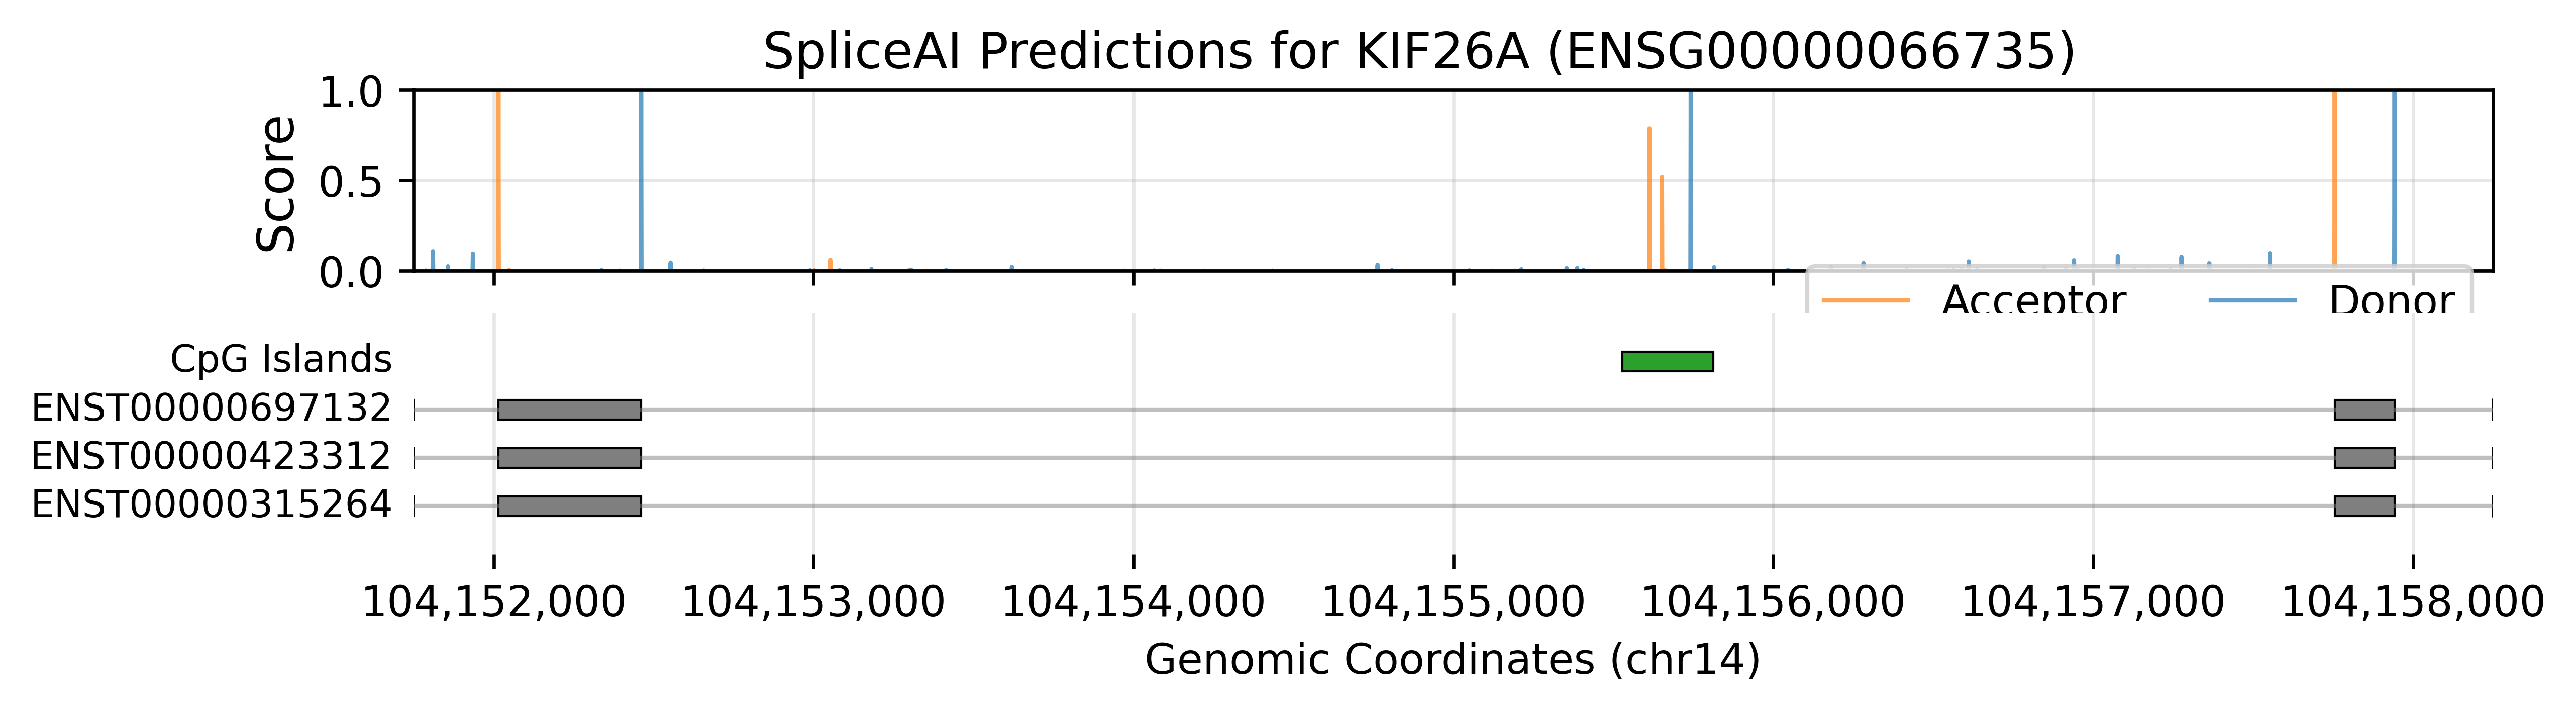

In [19]:
GENE_ID = "ENSG00000066735"

results = analyze_gene(
    GENE_ID, 
    gff, 
    genome, 
    spliceai_models,
    include_all_isoforms=True,
    include_overlapping_genes=False,
    custom_tracks=[{
        "name": "CpG Islands",
        "regions": [(104155529, 104155812), (104158911, 104159185)],
        "color": "tab:green",
        "label": "CpG Islands",
    }],
    region_of_interest=(104151750, 104158250),
    bbox_to_anchor=(1, -0.5),
    figsize=(8.9,2),
    dpi=600
)
    
results["figure"].savefig(f"figures/{GENE_ID}_SpliceAI_Predictions.svg", dpi=600)